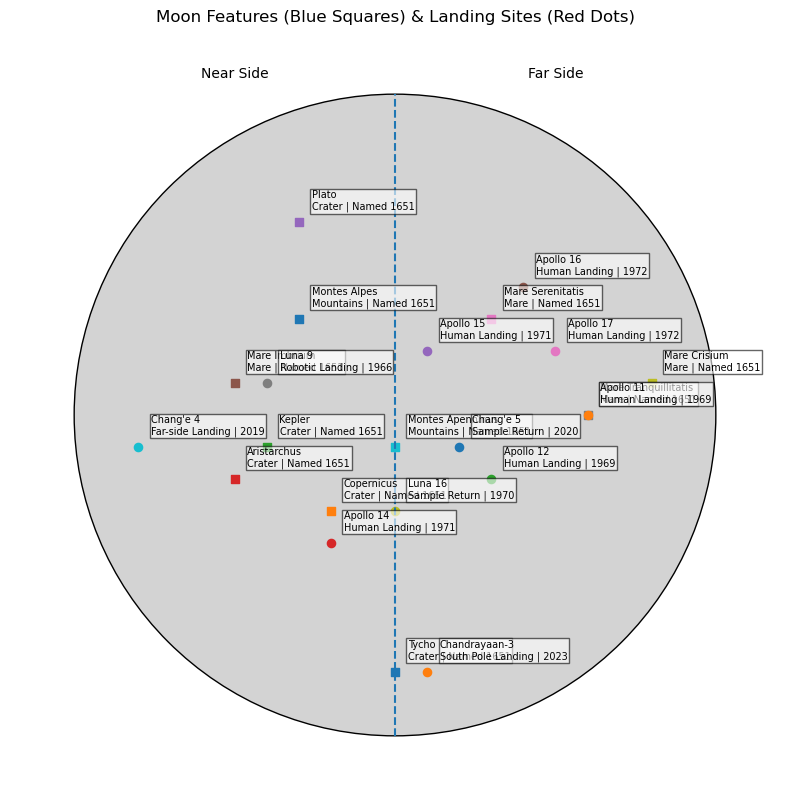

In [1]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

# Draw Moon
moon = plt.Circle((0, 0), 1, color='lightgray', ec='black')
ax.add_patch(moon)

# Divide near/far side
ax.plot([0, 0], [-1, 1], linestyle='--')

# --- Lunar Features (blue squares) ---
features = [
    ("Tycho", 0.0, -0.8, "Crater", "Named 1651"),
    ("Copernicus", -0.2, -0.3, "Crater", "Named 1651"),
    ("Kepler", -0.4, -0.1, "Crater", "Named 1651"),
    ("Aristarchus", -0.5, -0.2, "Crater", "Named 1651"),
    ("Plato", -0.3, 0.6, "Crater", "Named 1651"),
    ("Mare Imbrium", -0.5, 0.1, "Mare", "Named 1651"),
    ("Mare Serenitatis", 0.3, 0.3, "Mare", "Named 1651"),
    ("Mare Tranquillitatis", 0.6, 0.0, "Mare", "Named 1651"),
    ("Mare Crisium", 0.8, 0.1, "Mare", "Named 1651"),
    ("Montes Apenninus", 0.0, -0.1, "Mountains", "Named 1651"),
    ("Montes Alpes", -0.3, 0.3, "Mountains", "Named 1651"),
]

# --- Landing Sites (red dots) ---
sites = [
    ("Apollo 11", 0.6, 0.0, "Human Landing", "1969"),
    ("Apollo 12", 0.3, -0.2, "Human Landing", "1969"),
    ("Apollo 14", -0.2, -0.4, "Human Landing", "1971"),
    ("Apollo 15", 0.1, 0.2, "Human Landing", "1971"),
    ("Apollo 16", 0.4, 0.4, "Human Landing", "1972"),
    ("Apollo 17", 0.5, 0.2, "Human Landing", "1972"),
    ("Luna 9", -0.4, 0.1, "Robotic Landing", "1966"),
    ("Luna 16", 0.0, -0.3, "Sample Return", "1970"),
    ("Chang'e 4", -0.8, -0.1, "Far-side Landing", "2019"),
    ("Chang'e 5", 0.2, -0.1, "Sample Return", "2020"),
    ("Chandrayaan-3", 0.1, -0.8, "South Pole Landing", "2023"),
]

# Plot features
for name, x, y, ftype, year in features:
    ax.scatter(x, y, marker='s', s=40)
    ax.text(
        x + 0.04, y + 0.04,
        f"{name}\n{ftype} | {year}",
        fontsize=7,
        bbox=dict(facecolor='white', alpha=0.6, pad=1)
    )

# Plot landing sites
for name, x, y, ltype, year in sites:
    ax.scatter(x, y, marker='o', s=35)
    ax.text(
        x + 0.04, y + 0.04,
        f"{name}\n{ltype} | {year}",
        fontsize=7,
        bbox=dict(facecolor='white', alpha=0.6, pad=1)
    )

# Labels for sides
ax.text(-0.5, 1.05, "Near Side", ha='center', fontsize=10)
ax.text(0.5, 1.05, "Far Side", ha='center', fontsize=10)

# Formatting
ax.set_aspect('equal')
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.axis('off')

plt.title("Moon Features (Blue Squares) & Landing Sites (Red Dots)")
plt.show()

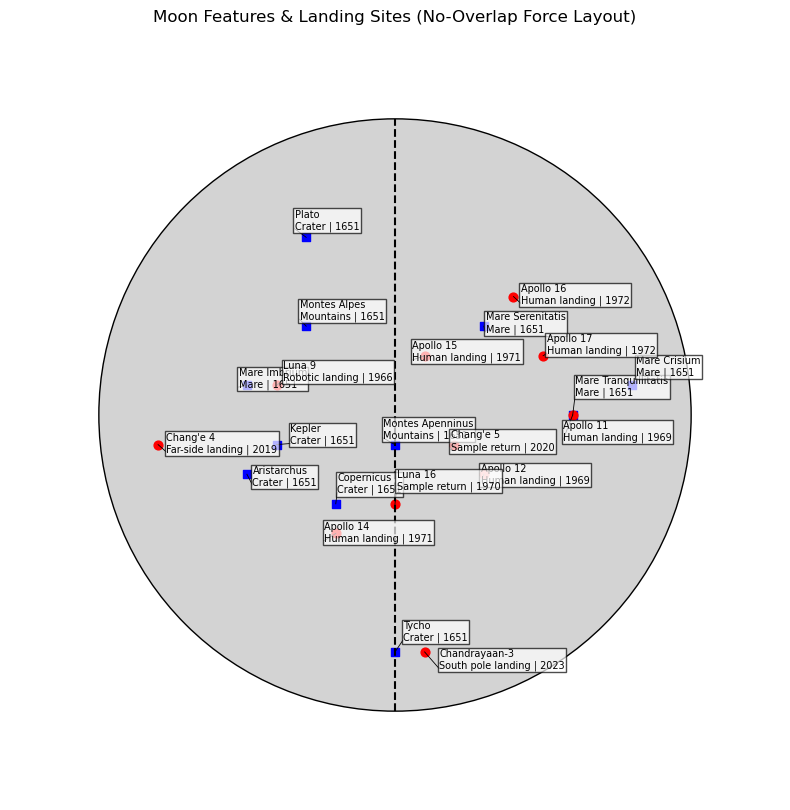

In [7]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 10))

# Moon
moon = plt.Circle((0, 0), 1, color='lightgray', ec='black')
ax.add_patch(moon)

ax.plot([0, 0], [-1, 1], linestyle='--', color='black')

feature_color = "blue"
landing_color = "red"

features = [
    ("Tycho", 0.0, -0.8, "Crater", "1651"),
    ("Copernicus", -0.2, -0.3, "Crater", "1651"),
    ("Kepler", -0.4, -0.1, "Crater", "1651"),
    ("Aristarchus", -0.5, -0.2, "Crater", "1651"),
    ("Plato", -0.3, 0.6, "Crater", "1651"),
    ("Mare Imbrium", -0.5, 0.1, "Mare", "1651"),
    ("Mare Serenitatis", 0.3, 0.3, "Mare", "1651"),
    ("Mare Tranquillitatis", 0.6, 0.0, "Mare", "1651"),
    ("Mare Crisium", 0.8, 0.1, "Mare", "1651"),
    ("Montes Apenninus", 0.0, -0.1, "Mountains", "1651"),
    ("Montes Alpes", -0.3, 0.3, "Mountains", "1651"),
]

sites = [
    ("Apollo 11", 0.6, 0.0, "Human landing", "1969"),
    ("Apollo 12", 0.3, -0.2, "Human landing", "1969"),
    ("Apollo 14", -0.2, -0.4, "Human landing", "1971"),
    ("Apollo 15", 0.1, 0.2, "Human landing", "1971"),
    ("Apollo 16", 0.4, 0.4, "Human landing", "1972"),
    ("Apollo 17", 0.5, 0.2, "Human landing", "1972"),
    ("Luna 9", -0.4, 0.1, "Robotic landing", "1966"),
    ("Luna 16", 0.0, -0.3, "Sample return", "1970"),
    ("Chang'e 4", -0.8, -0.1, "Far-side landing", "2019"),
    ("Chang'e 5", 0.2, -0.1, "Sample return", "2020"),
    ("Chandrayaan-3", 0.1, -0.8, "South pole landing", "2023"),
]

# store label objects
labels = []

# initial scatter + labels
def add_points(data, marker, color):
    for name, x, y, typ, year in data:
        ax.scatter(x, y, marker=marker, color=color, s=40)

        txt = ax.text(
            x, y,
            f"{name}\n{typ} | {year}",
            fontsize=7,
            bbox=dict(facecolor='white', alpha=0.7, pad=1)
        )

        labels.append((txt, x, y))

add_points(features, 's', feature_color)
add_points(sites, 'o', landing_color)

# -----------------------------
# 🔥 Collision-avoidance engine
# -----------------------------
def get_bbox(txt):
    renderer = fig.canvas.get_renderer()
    bbox = txt.get_window_extent(renderer=renderer)
    inv = ax.transData.inverted()
    return inv.transform(bbox)

def overlap(a, b):
    (x0, y0), (x1, y1) = a
    (x2, y2), (x3, y3) = b
    return not (x1 < x2 or x3 < x0 or y1 < y2 or y3 < y0)

# initialize random jitter so they don't start identical
for txt, x, y in labels:
    txt.set_position((x + np.random.uniform(-0.05, 0.05),
                      y + np.random.uniform(-0.05, 0.05)))

# force-based relaxation
for _ in range(150):  # iterations
    moved = False

    for i in range(len(labels)):
        t1, x1, y1 = labels[i]
        p1 = np.array(t1.get_position())

        for j in range(i + 1, len(labels)):
            t2, x2, y2 = labels[j]
            p2 = np.array(t2.get_position())

            # simple distance repulsion if too close
            delta = p1 - p2
            dist = np.linalg.norm(delta)

            if dist < 0.15:
                if dist == 0:
                    delta = np.random.randn(2) * 0.01
                    dist = 0.01

                shift = (delta / dist) * 0.01
                p1 += shift
                p2 -= shift

                t1.set_position(p1)
                t2.set_position(p2)
                moved = True

    if not moved:
        break

# draw connectors
for txt, x, y in labels:
    lx, ly = txt.get_position()
    ax.plot([x, lx], [y, ly], color='black', lw=0.6)

# formatting
ax.set_aspect('equal')
ax.set_xlim(-1.3, 1.3)
ax.set_ylim(-1.3, 1.3)
ax.axis('off')

plt.title("Moon Features & Landing Sites (No-Overlap Force Layout)")
plt.show()